In [ ]:
# Кластеризация KMeans на Iris

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

# Загрузка данных
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Данные стандартизированы: среднее =", X_scaled.mean(axis=0).round(2), ", стд =", X_scaled.std(axis=0).round(2))

Данные стандартизированы: среднее = [-0. -0. -0. -0.] , стд = [1. 1. 1. 1.]


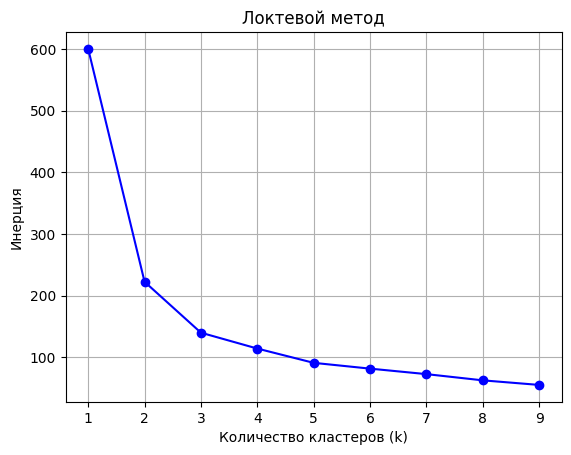

In [ ]:
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Инерция')
plt.title('Локтевой метод')
plt.grid(True)
plt.show()

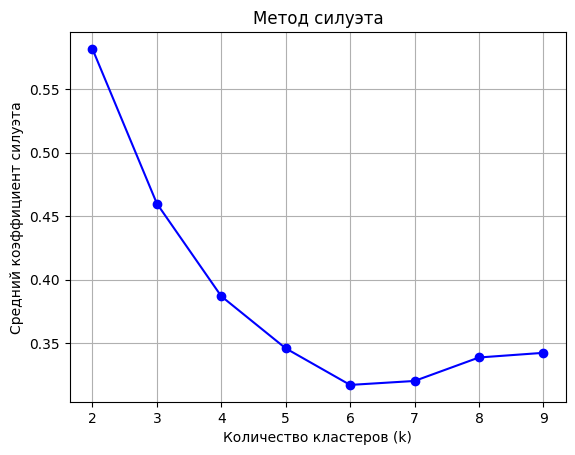

In [ ]:
silhouette_scores = []
K_range2 = range(2, 10)
for k in K_range2:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(K_range2, silhouette_scores, 'bo-')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Средний коэффициент силуэта')
plt.title('Метод силуэта')
plt.grid(True)
plt.show()

In [ ]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_

print("Кластерные центры (стандартизированные):")
print(pd.DataFrame(centroids, columns=feature_names))

Кластерные центры (стандартизированные):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.050220         -0.883376           0.347738          0.281527
1          -1.014579          0.853263          -1.304987         -1.254893
2           1.135970          0.088422           0.996155          1.017526


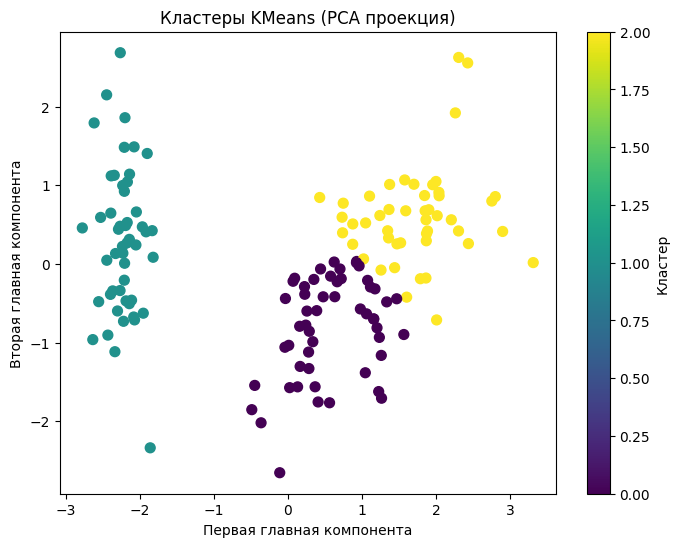

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Кластеры KMeans (PCA проекция)')
plt.colorbar(scatter, label='Кластер')
plt.show()

In [ ]:
ari = adjusted_rand_score(y, cluster_labels)
silhouette = silhouette_score(X_scaled, cluster_labels)
print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"Silhouette Score: {silhouette:.3f}")

# Сопоставление кластеров с истинными видами
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]
df['cluster'] = cluster_labels
cross = pd.crosstab(df['species'], df['cluster'])
print("\nТаблица сопоставления:")
print(cross)

Adjusted Rand Index (ARI): 0.620
Silhouette Score: 0.460

Таблица сопоставления:
cluster      0   1   2
species               
setosa       0  50   0
versicolor  39   0  11
virginica   14   0  36
